In [4]:
#STEP01: Import Libraries & Load Dataset
# Import essential libraries
import pandas as pd   # to handle data
import numpy as np    # for numerical operations
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for nice visual

In [5]:
# Load the dataset
df = pd.read_csv("Dentistry Dataset.csv")

# Preview first 5 rows
df.head()

,Sl No,Sample ID,Age,Gender,inter canine distance intraoral,intercanine distance casts,right canine width intraoral,right canine width casts,left canine width intraoral,left canine width casts,right canine index intra oral,right canine index casts,left canine index intraoral,left canine index casts
0,1,NaN,24,Female,25.06,25.05,6.08,6.08,6.09,6.10,0.242,0.242,0.242,0.241
1,2,NaN,22,Female,25.78,25.79,6.13,6.13,6.33,6.33,0.237,0.237,0.247,0.247
2,3,NaN,23,Female,23.83,23.83,5.91,5.96,6.28,6.28,0.248,0.248,0.264,0.264
3,4,NaN,20,Female,26.12,26.12,6.08,6.08,6.56,6.56,0.232,0.232,0.250,0.250
4,5,NaN,20,Female,26.36,26.41,6.09,6.09,6.50,6.50,0.231,0.231,0.246,0.246


In [6]:
#STEP02:Clean the Data
# Check shape and data types
print(df.shape)
df.info()

# Drop unnecessary columns
df.drop(columns=['Sl No','Sample ID'], inplace=True)

# Check for missing values
df.isnull().sum()

(1100, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Sl No                            1100 non-null   int64  
 1   Sample ID                        0 non-null      float64
 2   Age                              1100 non-null   int64  
 3   Gender                           1100 non-null   object 
 4   inter canine distance intraoral  1100 non-null   float64
 5   intercanine distance casts       1100 non-null   float64
 6   right canine width intraoral     1100 non-null   float64
 7   right canine width casts         1100 non-null   float64
 8   left canine width intraoral      1100 non-null   float64
 9   left canine width casts          1100 non-null   float64
 10  right canine index intra oral    1100 non-null   float64
 11  right canine index casts         1100 non-null   float64
 12  left cani

,0
Age,0
Gender,0
inter canine distance intraoral,0
intercanine distance casts,0
right canine width intraoral,0
right canine width casts,0
left canine width intraoral,0
left canine width casts,0
right canine index intra oral,0
right canine index casts,0


In [7]:
#STEP03: Explore the Data (EDA)
# See column names and data types
df.info()

# Gender value counts
print(df["Gender"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Age                              1100 non-null   int64  
 1   Gender                           1100 non-null   object 
 2   inter canine distance intraoral  1100 non-null   float64
 3   intercanine distance casts       1100 non-null   float64
 4   right canine width intraoral     1100 non-null   float64
 5   right canine width casts         1100 non-null   float64
 6   left canine width intraoral      1100 non-null   float64
 7   left canine width casts          1100 non-null   float64
 8   right canine index intra oral    1100 non-null   float64
 9   right canine index casts         1100 non-null   float64
 10  left canine index intraoral      1100 non-null   float64
 11  left canine index casts          1100 non-null   float64
dtypes: float64(10), int6

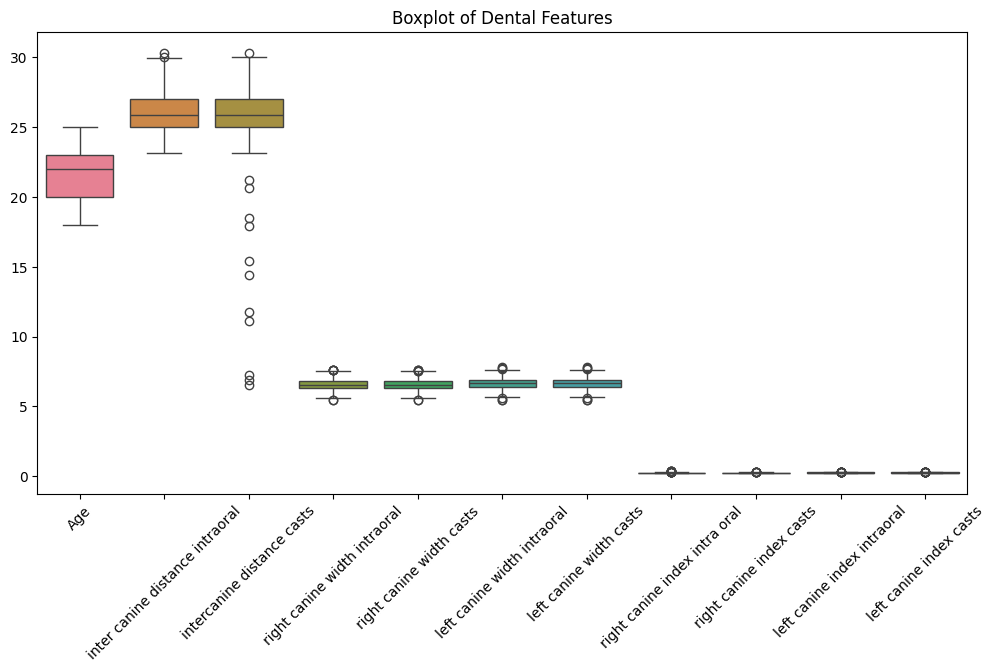

In [8]:
# Boxplot to check outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=["Gender"]))
plt.title("Boxplot of Dental Features")
plt.xticks(rotation=45)
plt.show()

In [9]:
#Step04: Encode & Normalize the Data
from sklearn.preprocessing import LabelEncoder, Normalizer

# Encode Gender: Female → 0, Male → 1
encoder = LabelEncoder()
df["Gender"] = encoder.fit_transform(df["Gender"])

# Separate X (features) and y (target)
X = df.drop("Gender", axis=1)
y = df["Gender"]

# Normalize the features
normalizer = Normalizer()
X = pd.DataFrame(normalizer.fit_transform(X), columns=X.columns)

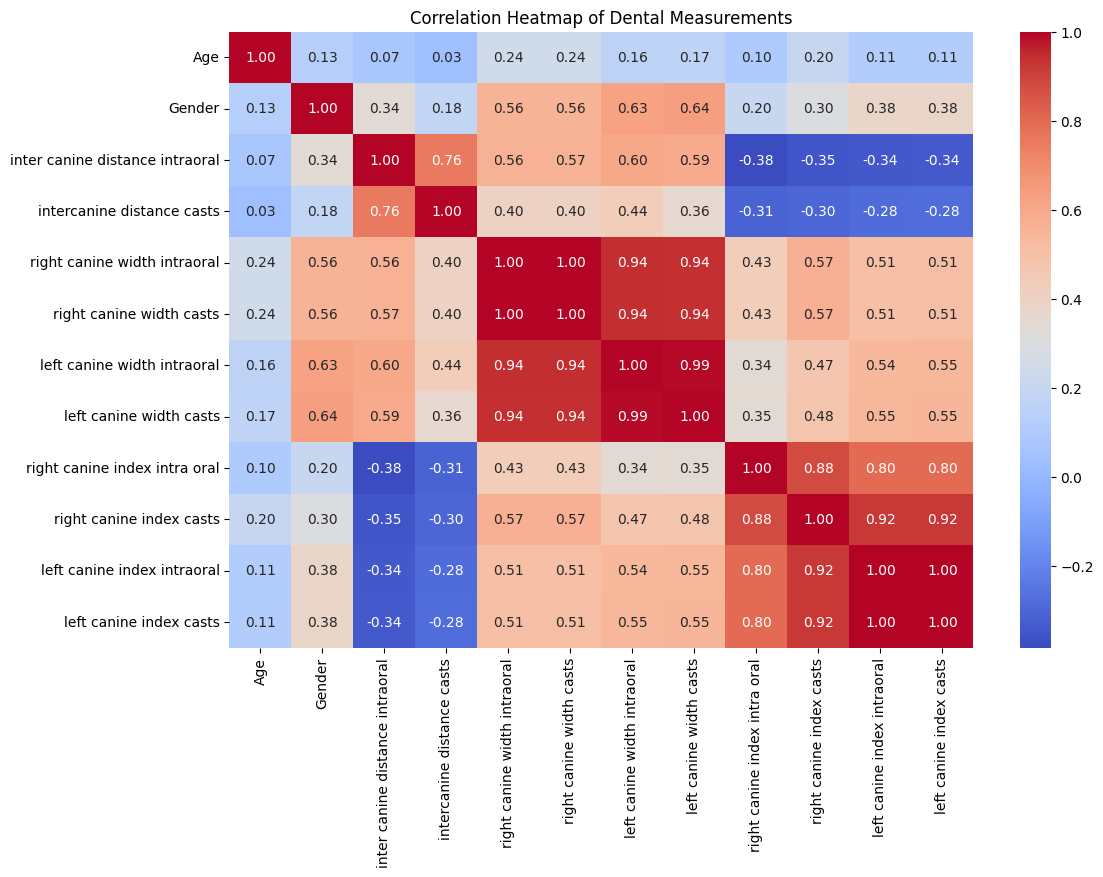

In [10]:
#Step05: Check for Correlation
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Dental Measurements")
plt.show()

In [11]:
#Step06: Split Data & Train Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier()
}

# Train and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")


Logistic Regression Accuracy: 0.6636
Decision Tree Accuracy: 0.8773
Random Forest Accuracy: 0.9000
XGBoost Accuracy: 0.8909


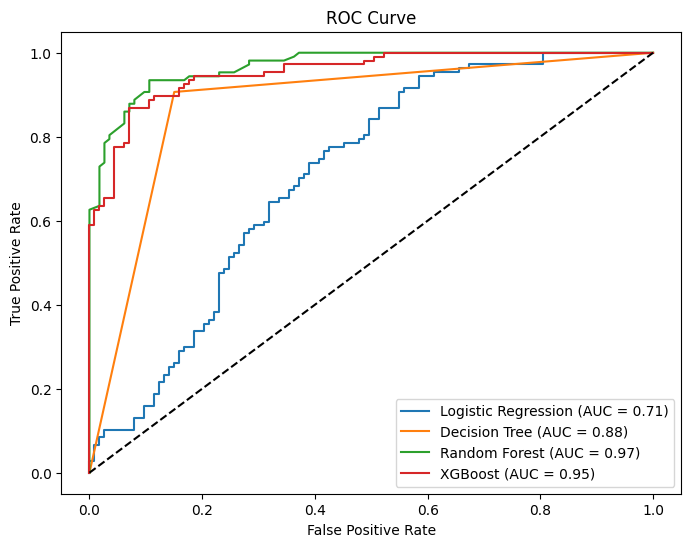

In [12]:
#Step07: Evaluate with Confusion Matrix & ROC Curve
from sklearn.metrics import confusion_matrix, roc_curve, auc

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [16]:
#Step08: Final Output / Report
# Save predictions (optional)
best_model = XGBClassifier()
best_model.fit(X_train, y_train)
predictions = best_model.predict(X_test)

# Save to CSV
output = pd.DataFrame({"Actual": y_test, "Predicted": predictions})
output.to_csv("gender_predictions.csv", index=False)
print(output)

     Actual  Predicted
328       0          0
688       1          1
413       0          1
788       1          1
244       0          0
..      ...        ...
319       0          1
979       1          1
919       1          1
989       1          1
724       1          1

[220 rows x 2 columns]
